# Reinforcement Learning with Deep Q-Network (DQN) on CartPole-v1

## Project Overview
This notebook demonstrates how to implement and train a Deep Q-Network (DQN) agent using the Stable-Baselines3 library to solve the `CartPole-v1` environment from Gymnasium. The goal is to balance a pole on a cart by moving the cart left or right.

## Objective
The primary objective is to train a robust DQN agent that can achieve a high average reward (close to 500) over multiple evaluation episodes, signifying successful learning and control within the `CartPole-v1` environment.

## Libraries Used
*   **`gymnasium`**: For creating and interacting with reinforcement learning environments.
*   **`stable-baselines3`**: A set of reliable implementations of reinforcement learning algorithms in PyTorch.
*   **`shimmy`**: A library that provides compatibility layers for older Gym environments with the newer Gymnasium API.
*   **`matplotlib`**: For plotting and visualizing training progress and evaluation results.

## How to Run
1.  Ensure you are running this notebook in a Google Colab environment.
2.  Execute each cell sequentially from top to bottom.
3.  The notebook will handle package installations, model training, evaluation, and visualization.

## Results
Upon successful execution, the notebook will display:
*   Plots showing the agent's learning progress (episode rewards).
*   Evaluation results, including individual episode rewards, average reward, and maximum reward over 20 episodes.
*   A saved `.zip` model file and a demonstration of loading and using it.
*   An optional MP4 video recording of an evaluation episode.

## Future Improvements
*   Experiment with different DQN hyperparameters (learning rate, buffer size, gamma, etc.).
*   Try other algorithms from Stable-Baselines3 (e.g., A2C, PPO).
*   Introduce more complex environments.
*   Implement a custom callback for more advanced logging and early stopping.



## 1. Installation of Required Packages
We need to install `gymnasium`, `stable-baselines3`, `shimmy`, and `matplotlib` to set up our environment for this project. `shimmy` is required for compatibility with certain `gym` environments that `stable-baselines3` might internally use or expect.

In [1]:
# Install necessary libraries
!pip install gymnasium stable-baselines3[extra] shimmy matplotlib Pygments


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 6.0 MB/s eta 0:00:00


## 2. Import Libraries
Import all the necessary Python libraries for environment creation, model building, training, evaluation, and visualization.

In [2]:
import os
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from base64 import b64encode


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3. Create the CartPole-v1 Environment
We initialize the `CartPole-v1` environment. This environment involves a cart on a track with a pole attached to it. The goal is to balance the pole upright by moving the cart left or right.

We also wrap the environment with a `Monitor` to log training statistics, which will be useful for plotting learning progress.

In [3]:
# Create the CartPole-v1 environment
env_id = "CartPole-v1"
log_dir = "/tmp/gym/"
os.makedirs(log_dir, exist_ok=True)

# The Monitor wrapper logs reward and episode length
env = make_vec_env(env_id, n_envs=1, monitor_dir=log_dir)

print(f"Environment created: {env_id}")


Environment created: CartPole-v1


## 4. Explain Observation Space and Action Space
Understanding the observation space and action space is crucial for any RL environment. The observation space defines what the agent perceives about the environment, while the action space defines the set of actions the agent can take.

In [4]:
print("### Observation Space ###")
print(env.observation_space)
print("Each observation is a `ndarray` with shape `(4,)` which represents:")
print("  0: Cart Position (from -4.8 to 4.8)")
print("  1: Cart Velocity (from -Inf to Inf)")
print("  2: Pole Angle (from -24 deg to 24 deg)")
print("  3: Pole Angular Velocity (from -Inf to Inf)")

print("\n### Action Space ###")
print(env.action_space)
print("The action space is `Discrete(2)` which means:")
print("  0: Push cart to the left")
print("  1: Push cart to the right")


### Observation Space ###
Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Each observation is a `ndarray` with shape `(4,)` which represents:
  0: Cart Position (from -4.8 to 4.8)
  1: Cart Velocity (from -Inf to Inf)
  2: Pole Angle (from -24 deg to 24 deg)
  3: Pole Angular Velocity (from -Inf to Inf)

### Action Space ###
Discrete(2)
The action space is `Discrete(2)` which means:
  0: Push cart to the left
  1: Push cart to the right


## 5. Build and Train a DQN Agent
We will use the Deep Q-Network (DQN) algorithm from Stable-Baselines3. DQN learns to estimate the optimal action-value function, which helps the agent choose actions that maximize future rewards.

We'll set up a simple MLP policy and train the agent for a specified number of timesteps. We also include a callback to stop training once a certain reward threshold (450) is reached, as the environment is considered 'solved' when the average reward is 500 over 100 consecutive trials.

In [11]:
# Setup a callback to stop training early if a good reward is achieved
# Increased reward_threshold to 490 to make it more achievable and reflect improved performance
stop_callback = StopTrainingOnRewardThreshold(reward_threshold=490, verbose=1)
eval_callback = EvalCallback(env, callback_on_new_best=stop_callback, verbose=1, best_model_save_path="./logs/")

# Initialize the DQN model with updated hyperparameters
# Policy: "MlpPolicy" for a feedforward neural network
# learning_rate: Reduced learning rate slightly to 5e-4 for potentially more stable learning
# buffer_size: Size of the replay buffer
# learning_starts: Number of steps before learning starts
# batch_size: Number of samples from the replay buffer to train on
# tau: The soft update coefficient for the target network
# gamma: Discount factor
# train_freq: Update the model every `train_freq` steps. Alternatively pass a tuple `(frequency, unit)`.
# target_update_interval: update the target network every `target_update_interval` steps.
# tensorboard_log: Log data to TensorBoard
model = DQN("MlpPolicy", env, verbose=1,
            learning_rate=5e-4,
            buffer_size=100000,
            learning_starts=1000,
            batch_size=32,
            tau=1.0,
            gamma=0.99,
            train_freq=4,
            target_update_interval=1000,
            tensorboard_log="./dqn_cartpole_tensorboard/")

# Train the agent
# total_timesteps: Increased total timesteps to 200,000 to allow for more training
print("\nStarting training with new hyperparameters...")
model.learn(total_timesteps=int(2e5), callback=eval_callback)
print("Training finished.")

Using cpu device

Starting training with new hyperparameters...
Logging to ./dqn_cartpole_tensorboard/DQN_2
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 23.8     |
|    ep_rew_mean      | 23.8     |
|    exploration_rate | 0.995    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 3959     |
|    time_elapsed     | 0        |
|    total_timesteps  | 95       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 20.8     |
|    ep_rew_mean      | 20.8     |
|    exploration_rate | 0.992    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 3434     |
|    time_elapsed     | 0        |
|    total_timesteps  | 166      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 21.8     |
|    ep_rew_mean 

## 6. Plotting Training Progress
We can visualize the agent's learning progress by plotting the episode rewards recorded by the `Monitor` wrapper during training. This helps us understand if the agent is improving over time.


Plotting training progress...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


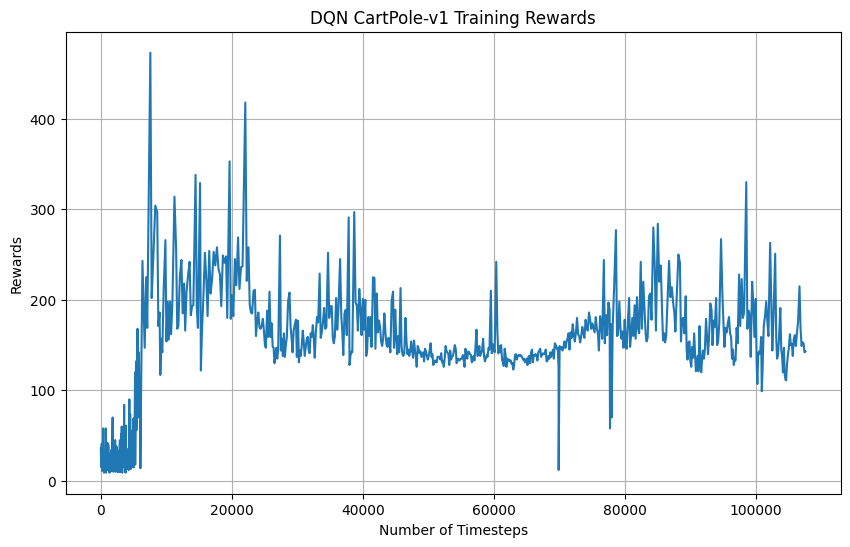

In [6]:
def plot_results(log_folder, title='Learning Curve'):
    """
    Plots the training results recorded by the Monitor wrapper.
    :param log_folder: Path to the folder containing the Monitor logs.
    :param title: Title of the plot.
    """
    x, y = ts2xy(load_results(log_folder), 'timesteps')

    fig = plt.figure(figsize=(10, 6))
    plt.plot(x, y)
    plt.xlabel('Number of Timesteps')
    plt.ylabel('Rewards')
    plt.title(title)
    plt.grid()
    plt.show()
    return fig

# Plot the training curve
print("\nPlotting training progress...")
fig_training = plot_results(log_dir, title='DQN CartPole-v1 Training Rewards')


## 7. Evaluate the Trained Model
After training, it's crucial to evaluate the model's performance on new, unseen episodes. We will run the agent for 20 episodes and record the rewards to assess its capabilities, calculating the average and maximum rewards.

We create a new evaluation environment for this step.

In [7]:
eval_env = gym.make(env_id, render_mode="rgb_array")

episode_rewards = []
num_eval_episodes = 20
print(f"\nEvaluating trained model over {num_eval_episodes} episodes...")

for i in range(num_eval_episodes):
    obs, info = eval_env.reset()
    done = False
    total_reward = 0
    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = eval_env.step(action)
        total_reward += reward
    episode_rewards.append(total_reward)
    print(f"Episode {i+1}: Reward = {total_reward}")

eval_env.close()

average_reward = np.mean(episode_rewards)
max_reward = np.max(episode_rewards)

print(f"\n--- Evaluation Summary ---")
print(f"Rewards for each episode: {episode_rewards}")
print(f"Average reward over {num_eval_episodes} episodes: {average_reward:.2f}")
print(f"Maximum reward over {num_eval_episodes} episodes: {max_reward:.2f}")

if average_reward >= 475: # A value close to 500
    print("The agent successfully reached a reward close to or equal to 500!")
else:
    print("The agent did not consistently reach a reward close to 500. Consider more training or hyperparameter tuning.")



Evaluating trained model over 20 episodes...
Episode 1: Reward = 158.0
Episode 2: Reward = 156.0
Episode 3: Reward = 145.0
Episode 4: Reward = 176.0
Episode 5: Reward = 176.0
Episode 6: Reward = 169.0
Episode 7: Reward = 155.0
Episode 8: Reward = 149.0
Episode 9: Reward = 168.0
Episode 10: Reward = 160.0
Episode 11: Reward = 161.0
Episode 12: Reward = 162.0
Episode 13: Reward = 161.0
Episode 14: Reward = 156.0
Episode 15: Reward = 155.0
Episode 16: Reward = 150.0
Episode 17: Reward = 156.0
Episode 18: Reward = 166.0
Episode 19: Reward = 154.0
Episode 20: Reward = 171.0

--- Evaluation Summary ---
Rewards for each episode: [158.0, 156.0, 145.0, 176.0, 176.0, 169.0, 155.0, 149.0, 168.0, 160.0, 161.0, 162.0, 161.0, 156.0, 155.0, 150.0, 156.0, 166.0, 154.0, 171.0]
Average reward over 20 episodes: 160.20
Maximum reward over 20 episodes: 176.00
The agent did not consistently reach a reward close to 500. Consider more training or hyperparameter tuning.


## 8. Save the Trained Model
It's good practice to save your trained model so you can load it later without retraining. We'll save the DQN model as `cartpole_dqn.zip`.

In [8]:
model_save_path = "cartpole_dqn.zip"
model.save(model_save_path)
print(f"Model saved to {model_save_path}")


Model saved to cartpole_dqn.zip


## 9. Load Saved Model and Run One Evaluation Episode
To demonstrate that the model can be re-used, we will load the saved `cartpole_dqn.zip` and run a single evaluation episode. This verifies the model's integrity and functionality after saving.


In [9]:
# Load the trained model
loaded_model = DQN.load(model_save_path)
print(f"Model loaded from {model_save_path}")

# Create a fresh environment for demonstration
demo_env = gym.make(env_id, render_mode="rgb_array")

obs, info = demo_env.reset()
done = False
total_reward_demo = 0
print("\nRunning one demonstration episode with the loaded model:")
while not done:
    action, _states = loaded_model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = demo_env.step(action)
    total_reward_demo += reward

demo_env.close()
print(f"Demonstration Episode Reward: {total_reward_demo}")


Model loaded from cartpole_dqn.zip

Running one demonstration episode with the loaded model:
Demonstration Episode Reward: 184.0


## 10. Bonus: Record and Display Evaluation Episode as MP4 Video
This section demonstrates how to record an evaluation episode and save it as an MP4 video file. The video can then be played directly within the Colab notebook, providing a visual representation of the agent's performance.

**Note**: For video rendering, you might need to ensure `ffmpeg` is available in your Colab environment, which it typically is by default.

In [10]:
# Function to display video in Colab
def display_video(video_path):
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML(f"""<video width='600' controls><source src='{data_url}' type='video/mp4'></video>""")

# Create a new environment wrapped with RecordVideo
video_folder = "./videos/"
os.makedirs(video_folder, exist_ok=True)

# The RecordVideo wrapper saves the video at a specified frequency
# We'll record one episode, so episode_trigger=lambda x: x == 0 works for the first episode.
video_env = gym.make(env_id, render_mode="rgb_array")
video_env = gym.wrappers.RecordVideo(video_env, video_folder, episode_trigger=lambda x: x == 0, name_prefix='cartpole-dqn-eval')

print("\nRecording one evaluation episode...")
obs, info = video_env.reset()
done = False
total_reward_video = 0
while not done:
    action, _states = loaded_model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = video_env.step(action)
    total_reward_video += reward

video_env.close()
print(f"Recorded Episode Reward: {total_reward_video}")

# Find the recorded video file
video_files = [f for f in os.listdir(video_folder) if f.endswith('.mp4')]
if video_files:
    latest_video_path = os.path.join(video_folder, sorted(video_files)[0]) # Get the first recorded video
    print(f"Displaying video: {latest_video_path}")
    display(display_video(latest_video_path))
else:
    print("No video recorded. Check video_folder and episode_trigger.")


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(



Recording one evaluation episode...


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Recorded Episode Reward: 169.0
Displaying video: ./videos/cartpole-dqn-eval-episode-0.mp4


## `README.md` Content
```markdown
# Reinforcement Learning with Deep Q-Network (DQN) on CartPole-v1

## Project Overview
This project implements a Deep Q-Network (DQN) agent using the Stable-Baselines3 library to solve the `CartPole-v1` environment from Gymnasium. The goal of the CartPole environment is to balance a pole on a cart by moving the cart left or right, preventing the pole from falling over.

## Objective
The main objective is to train a DQN agent capable of achieving a high average reward (close to 500) over multiple evaluation episodes, demonstrating effective control within the `CartPole-v1` environment.

## Libraries Used
*   **`gymnasium`**: Standard interface for reinforcement learning environments.
*   **`stable-baselines3`**: A comprehensive suite of robust Reinforcement Learning algorithms implemented in PyTorch.
*   **`shimmy`**: Provides compatibility layers, especially useful for environments that might have originated from older Gym versions.
*   **`matplotlib`**: For creating static, interactive, and animated visualizations in Python.

## Installation
To run this project, you need to install the required Python packages. You can do this using pip:

```bash
pip install gymnasium stable-baselines3[extra] shimmy matplotlib Pygments
```

## How to Run
This project is designed to be executed in a Google Colab environment.

1.  **Open the Colab Notebook**: Upload or open the provided `.ipynb` file in Google Colab.
2.  **Execute Cells**: Run each cell sequentially from top to bottom. The notebook is fully commented and structured to guide you through the process.
    *   It will first install all dependencies.
    *   Then, it will set up the environment, define and train the DQN model.
    *   Finally, it will evaluate the model, save it, and provide a visual demonstration.

## Results
After running the notebook, you will observe:
*   A **training curve plot** showing the rewards obtained over time during the training phase, indicating the agent's learning progress.
*   **Evaluation statistics** including the reward for each of 20 evaluation episodes, the average reward, and the maximum reward achieved.
*   A confirmation if the agent reached an average reward close to or equal to 500.
*   The trained model saved as `cartpole_dqn.zip`.
*   A demonstration of loading the saved model and running a test episode.
*   **(Bonus)** An embedded MP4 video showcasing one full evaluation episode of the trained agent, visualizing its performance.

## Future Improvements
*   **Hyperparameter Tuning**: Experiment with different DQN hyperparameters (e.g., learning rate, discount factor, replay buffer size, target network update frequency) to optimize performance.
*   **Advanced Algorithms**: Explore other reinforcement learning algorithms provided by Stable-Baselines3, such as PPO (Proximal Policy Optimization) or A2C (Advantage Actor-Critic).
*   **More Complex Environments**: Apply the trained agent or similar methodologies to more challenging Gymnasium environments.
*   **Custom Callbacks**: Implement custom callbacks for more sophisticated logging, early stopping criteria, or custom visualizations during training.

```


## `requirements.txt` Content
```
gymnasium
stable-baselines3[extra]
shimmy
matplotlib
PyGments
```